In [1]:
import pandas as pd
df=pd.read_csv("heart.csv")
print(df.head())
print(df.info())
print(df["target"].value_counts())

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca   target
0   49    0   3       177   150    0       95      0      2.3    0       0
1   56    1   0       124   172    1       86      1      0.5    0       1
2   66    0   3       100   239    0      105      0      1.7    0       0
3   64    0   0       168   222    0       95      1      2.8    0       1
4   60    1   2       153   358    0      147      0      3.2    0       1
<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       16 non-null     int64  
 1   sex       16 non-null     int64  
 2   cp        16 non-null     int64  
 3   trestbps  16 non-null     int64  
 4   chol      16 non-null     int64  
 5   fbs       16 non-null     int64  
 6   thalach   16 non-null     int64  
 7   exang     16 non-null     int64  
 8   oldpeak   16 non-null     float64
 9   ca        16 non-null   

In [4]:
x=df.drop("target",axis=1)
y=df["target"]
from sklearn.model_selection import train_test_split 
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [5]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)
pred=model.predict(x_test)
print(pred[:10])

[1 0 1 1]


In [7]:
from sklearn.metrics import (accuracy_score,confusion_matrix,precision_score,recall_score,f1_score)
acc=accuracy_score(y_test,pred)
cm=confusion_matrix(y_test,pred)
prec=precision_score(y_test,pred)
rec=recall_score(y_test,pred)
f1=f1_score(y_test,pred)
print(acc,prec,rec,f1)
print(cm)

0.25 0.3333333333333333 0.5 0.4
[[0 2]
 [1 1]]


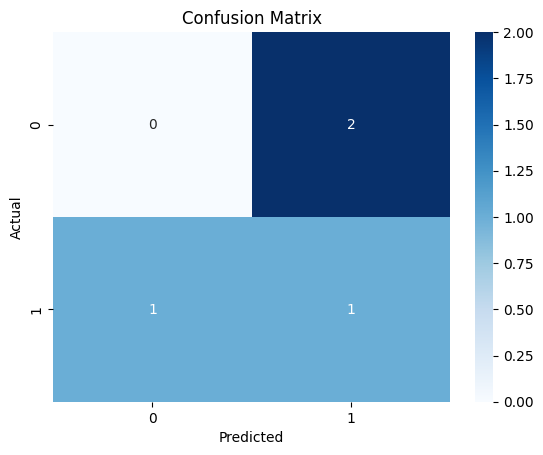

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [13]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
pred_knn=knn.predict(x_test)
print(accuracy_score(y_test,pred_knn))

0.5


In [14]:
for k in [1,3,5,7,9]:
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train,y_train)
    pred_k=knn.predict(x_test)
    acc_k=accuracy_score(y_test,pred_k)
    print("K=",k,"->Accuracy:",acc_k)

K= 1 ->Accuracy: 0.25
K= 3 ->Accuracy: 0.25
K= 5 ->Accuracy: 0.5
K= 7 ->Accuracy: 0.5
K= 9 ->Accuracy: 0.5
